### Connect to Kaggle

We will be using data available on Kaggle platform for this exercise. The data is available at https://www.kaggle.com/c/word2vec-nlp-tutorial/data.

Task to do https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews?resource=download

In [ ]:
# !pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [ ]:
from google.colab import files
uploaded=files.upload()

Saving labeledTrainData.tsv to labeledTrainData.tsv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Import the dataset as pandas dataframe

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_table('labeledTrainData.tsv')

In [ ]:
df = pd.read_table(r'/content/drive/MyDrive/NLPA - Natural Language Process and its Application Jan 2026/Nish/Unit 3/labeledTrainData.tsv')

In [ ]:
df.shape

(25000, 3)

In [ ]:
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         25000 non-null  object
 1   sentiment  25000 non-null  int64 
 2   review     25000 non-null  object
dtypes: int64(1), object(2)
memory usage: 586.1+ KB


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
1,12500
0,12500


In [ ]:
df.loc[200, 'review']

'It takes patience to get through David Lynch\'s eccentric, but-- for a change-- life-affirming chronicle of Alvin Straight\'s journey, but stick with it. Though it moves as slow as Straight\'s John Deere, when he meets the kind strangers along his pilgrimage we learn much about the isolation of aging, the painful regrets and secrets, and ultimately the power of family and reconciliation. Richard Farnsworth caps his career with the year\'s most genuine performance, sad and poetic, flinty and caring. And Sissy Spacek matches him as his \\slow\\" daughter Rose who pines over her own private loss while caring for dad. Rarely has a modern film preached so positively about family."'

In [ ]:
import re

def remove_tags(string):

    removelist = ""  # Add any characters you'd like to keep

    # Remove HTML tags

    result = re.sub(r'<[^>]+>', '', string)

    # Remove URLs

    result = re.sub(r'https?://\S+', '', result)

    # Remove non-alphanumeric characters (except for those in the removelist)

    result = re.sub(r'[^a-zA-Z0-9' + removelist + r'\s]', ' ', result)

    # Convert to lowercase

    result = result.lower()

    return result


In [ ]:
remove_tags(df.loc[200, 'review'])

'it takes patience to get through david lynch s eccentric  but   for a change   life affirming chronicle of alvin straight s journey  but stick with it  though it moves as slow as straight s john deere  when he meets the kind strangers along his pilgrimage we learn much about the isolation of aging  the painful regrets and secrets  and ultimately the power of family and reconciliation  richard farnsworth caps his career with the year s most genuine performance  sad and poetic  flinty and caring  and sissy spacek matches him as his  slow   daughter rose who pines over her own private loss while caring for dad  rarely has a modern film preached so positively about family  '

In [ ]:
df['clean_review']=df['review'].apply(lambda x: remove_tags(x))

In [ ]:
df.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,with all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",the classic war of the worlds by timothy hi...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,the film starts with a manager nicholas bell ...
3,3630_4,0,It must be assumed that those who praised this...,it must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy and wondrously unpretentious 8...


#### Split Data into Training and Test Data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df.head()

,id,sentiment,review,clean_review
0,5814_8,1,With all this stuff going down at the moment w...,with all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi...",the classic war of the worlds by timothy hi...
2,7759_3,0,The film starts with a manager (Nicholas Bell)...,the film starts with a manager nicholas bell ...
3,3630_4,0,It must be assumed that those who praised this...,it must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...,superbly trashy and wondrously unpretentious 8...


In [ ]:
df_processed =  df[['clean_review','sentiment']].copy()

# def sent (text):
#   if text == 'positive':
#     return 1
#   else:
#     return 0

# df_processed['sentiment'] = df_processed['sentiment'].apply(lambda x : sent(x))
df_processed.head()

,clean_review,sentiment
0,with all this stuff going down at the moment w...,1
1,the classic war of the worlds by timothy hi...,1
2,the film starts with a manager nicholas bell ...,0
3,it must be assumed that those who praised this...,0
4,superbly trashy and wondrously unpretentious 8...,1


In [ ]:
train, test = train_test_split(df_processed, test_size=0.2, random_state=42)

In [ ]:
train.shape, test.shape

((20000, 2), (5000, 2))

In [ ]:
train.head()

,clean_review,sentiment
23311,this movie is just plain dumb from the casting...,0
23623,dahmer a young confused man dahmer a confus...,0
1020,may the saints preserve us because this movie...,0
12645,the combination of reading the novella and vie...,1
1533,daniel day lewis in my left foot gives us one ...,1


In [ ]:
train.reset_index(inplace=True, drop=True)
test.reset_index(inplace=True, drop=True)

In [ ]:
train.head()

,clean_review,sentiment
0,this movie is just plain dumb from the casting...,0
1,dahmer a young confused man dahmer a confus...,0
2,may the saints preserve us because this movie...,0
3,the combination of reading the novella and vie...,1
4,daniel day lewis in my left foot gives us one ...,1


In [ ]:
X_train = train['clean_review']
y_train = train['sentiment']
X_test = test['clean_review']
y_test = test['sentiment']

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(20000,)
(20000,)
(5000,)
(5000,)


### 2. Build the Tokenizer

In [ ]:
import tensorflow as tf

In [ ]:
desired_vocab_size = 30000
oov_tok = "<OOV>"
t = tf.keras.preprocessing.text.Tokenizer(num_words=desired_vocab_size, oov_token=oov_tok)

In [ ]:
#Fit tokenizer with actual training data
t.fit_on_texts(X_train.tolist())

In [ ]:
len(t.word_index)

69146

In [ ]:
#Vocabulary
print(t.word_index)

{'<OOV>': 1, 'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'it': 8, 'in': 9, 'i': 10, 'this': 11, 'that': 12, 's': 13, 'was': 14, 'as': 15, 'movie': 16, 'for': 17, 'with': 18, 'but': 19, 'film': 20, 't': 21, 'on': 22, 'you': 23, 'not': 24, 'he': 25, 'his': 26, 'are': 27, 'have': 28, 'be': 29, 'one': 30, 'all': 31, 'at': 32, 'they': 33, 'by': 34, 'who': 35, 'an': 36, 'so': 37, 'from': 38, 'like': 39, 'there': 40, 'her': 41, 'or': 42, 'just': 43, 'about': 44, 'out': 45, 'has': 46, 'if': 47, 'what': 48, 'some': 49, 'good': 50, 'can': 51, 'more': 52, 'she': 53, 'when': 54, 'very': 55, 'up': 56, 'no': 57, 'even': 58, 'time': 59, 'my': 60, 'would': 61, 'which': 62, 'only': 63, 'story': 64, 'really': 65, 'see': 66, 'had': 67, 'their': 68, 'we': 69, 'me': 70, 'well': 71, 'were': 72, 'than': 73, 'much': 74, 'get': 75, 'been': 76, 'bad': 77, 'will': 78, 'people': 79, 'other': 80, 'also': 81, 'do': 82, 'into': 83, 'great': 84, 'first': 85, 'because': 86, 'him': 87, 'don': 88, 'how': 89, 

# Prepare Training and Test Data

Get the word index for each of the word in the review

In [ ]:
X_train[0]

'this movie is just plain dumb from the casting of ralph meeker as mike hammer to the fatuous climax  the film is an exercise in wooden predictability mike hammer is one of detective fiction s true sociopaths  unlike marlow and spade  who put pieces together to solve the mystery  hammer breaks things apart to get to the truth  this film turns hammer into a boob by surrounding him with bad guys who are     well  too dumb to get away with anything  one is so poorly drawn that he succumbs to a popcorn attack other parts of the movie are right out of the three stooges play book  velda s dance at the barre  for instance  or the bad guy who accidentally stabs his boss in the back  and the continuity breaks are shameful  frau blucher is running down the centerline of the road when the camera is tight on her lower legs but she s way over the side when the camera pulls back for a wider shot  the worst break  however  precedes the popcorn attack  the bad guy stalking hammer passes a clock second

In [ ]:
X_train = t.texts_to_sequences(X_train.tolist())

In [ ]:
print(X_train[0])

[11, 16, 7, 43, 1050, 964, 38, 2, 975, 5, 2850, 12429, 15, 1808, 4008, 6, 2, 21861, 1348, 2, 20, 7, 36, 3269, 9, 1598, 8676, 1808, 4008, 7, 30, 5, 1217, 1207, 13, 282, 23737, 1013, 29480, 3, 7145, 35, 269, 1272, 292, 6, 3347, 2, 717, 4008, 2009, 184, 983, 6, 75, 6, 2, 887, 11, 20, 500, 4008, 83, 4, 9810, 34, 3478, 87, 18, 77, 473, 35, 27, 71, 98, 964, 6, 75, 244, 18, 230, 30, 7, 37, 840, 1278, 12, 25, 16005, 6, 4, 3717, 1226, 80, 539, 5, 2, 16, 27, 205, 45, 5, 2, 291, 4754, 297, 267, 1, 13, 828, 32, 2, 1, 17, 1853, 42, 2, 77, 223, 35, 2533, 8122, 26, 1355, 9, 2, 145, 3, 2, 2341, 2009, 27, 8123, 29481, 1, 7, 621, 181, 2, 1, 5, 2, 1276, 54, 2, 368, 7, 2612, 22, 41, 2360, 2979, 19, 53, 13, 96, 120, 2, 495, 54, 2, 368, 2613, 145, 17, 4, 6470, 324, 2, 245, 1001, 192, 15255, 2, 3717, 1226, 2, 77, 223, 5942, 4008, 3877, 4, 5354, 1555, 100, 264, 596, 533, 2, 5354, 287, 25, 14, 1500, 233, 499, 264, 223, 6, 29, 1290, 40, 72, 49, 222, 368, 2408, 3, 1532, 3, 2, 1682, 1976, 7, 37, 77, 12, 8, 207, 7

In [ ]:
t.sequences_to_texts([X_train[0]])

['this movie is just plain dumb from the casting of ralph meeker as mike hammer to the fatuous climax the film is an exercise in wooden predictability mike hammer is one of detective fiction s true sociopaths unlike marlow and spade who put pieces together to solve the mystery hammer breaks things apart to get to the truth this film turns hammer into a boob by surrounding him with bad guys who are well too dumb to get away with anything one is so poorly drawn that he succumbs to a popcorn attack other parts of the movie are right out of the three stooges play book <OOV> s dance at the <OOV> for instance or the bad guy who accidentally stabs his boss in the back and the continuity breaks are shameful frau <OOV> is running down the <OOV> of the road when the camera is tight on her lower legs but she s way over the side when the camera pulls back for a wider shot the worst break however precedes the popcorn attack the bad guy stalking hammer passes a clock seconds after our hero except th

In [ ]:
X_test = t.texts_to_sequences(X_test.tolist())

How many words in each review?

In [ ]:
length =[]
for i in range(len(X_train)):
  length.append(len(X_train[i]))

In [ ]:
max(length), min(length)

(2498, 10)

In [ ]:
len(X_train[2000])

358

#### Pad Sequences - Important

In [ ]:
#Define maximum number of words to consider in each review
max_review_length = 300

In [ ]:
#Pad training and test reviews
X_train = tf.keras.preprocessing.sequence.pad_sequences(X_train,
                                                        maxlen=max_review_length,
                                                        padding='pre',
                                                        truncating='post')

X_test = tf.keras.preprocessing.sequence.pad_sequences(X_test,
                                                       maxlen=max_review_length,
                                                       padding='pre',
                                                       truncating='post')

In [ ]:
X_train.shape

(20000, 300)

In [ ]:
X_test.shape

(5000, 300)

In [ ]:
X_train[200]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,

### 3. Build the Graph

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Add Embedding layer
 - Embedding Layer Input = Batch_Size * Length of each review

In [ ]:
# model.add(tf.keras.layers.Embedding(input_dim=desired_vocab_size + 1, #Vocablury size
#                                     # embedding = 50 #Embedding size)

In [ ]:
desired_vocab_size

30000

In [ ]:
# First layer must be Input
model.add(tf.keras.layers.Input(shape=(max_review_length,)))

# Embedding layer
model.add(tf.keras.layers.Embedding(
        input_dim = desired_vocab_size + 1,
        output_dim = 50
))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 1,500,050 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Embedding Layer Output -
[Batch_Size , Review Length , Embedding_Size]

Flatten the Output

In [ ]:
model.add(tf.keras.layers.Flatten())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 1,500,050 (5.72 MB)

 Non-trainable params: 0 (0.00 B)

Add Dense Layer

In [ ]:
model.add(tf.keras.layers.BatchNormalization())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,560,050 (5.95 MB)

 Trainable params: 1,530,050 (5.84 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.add(tf.keras.layers.Dense(128, activation='relu'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,178 (13.28 MB)

 Trainable params: 3,450,178 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,178 (13.28 MB)

 Trainable params: 3,450,178 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

Use Dense layer for output layer

In [ ]:
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,307 (13.28 MB)

 Trainable params: 3,450,307 (13.16 MB)

 Non-trainable params: 30,000 (117.19 KB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.6329 - loss: 0.7513 - val_accuracy: 0.8660 - val_loss: 0.3679
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9662 - loss: 0.0974 - val_accuracy: 0.8252 - val_loss: 0.4973
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 73ms/step - accuracy: 0.9835 - loss: 0.0500 - val_accuracy: 0.8420 - val_loss: 0.5244
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9800 - loss: 0.0639 - val_accuracy: 0.8402 - val_loss: 0.6856
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.9862 - loss: 0.0445 - val_accuracy: 0.8492 - val_loss: 0.6164


#### Execute the graph

### 3. Using Pre-Trained Embeddings

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.2 MB/s eta 0:00:00


In [ ]:
!pip install gensim
import gensim.downloader as api
import numpy as np

Available Word2Vec/Glove Pretained models -> [Link](https://github.com/RaRe-Technologies/gensim-data)

In [ ]:
#Load Glove model (similar to Word2Vec)
glove_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
#Size of the model
glove_model.vectors.shape

(400000, 50)

In [ ]:
# glove_model.vocab

In [ ]:
glove_model['india']

array([-0.20356 , -0.8707  , -0.19172 ,  0.73862 ,  0.18494 ,  0.14926 ,
        0.48079 , -0.21633 ,  0.72753 , -0.36912 ,  0.13397 , -0.1143  ,
       -0.18075 , -0.64683 , -0.18484 ,  0.83575 ,  0.48179 ,  0.76026 ,
       -0.50381 ,  0.80743 ,  1.2195  ,  0.3459  ,  0.22185 ,  0.31335 ,
        1.2066  , -1.8441  ,  0.14064 , -0.99715 , -1.1402  ,  0.32342 ,
        3.2128  ,  0.42708 ,  0.19504 ,  0.80113 ,  0.38555 , -0.12568 ,
       -0.26533 ,  0.055264, -1.1557  ,  0.16836 , -0.82228 ,  0.20394 ,
        0.089235, -0.60125 , -0.032878,  1.3735  , -0.51661 ,  0.29611 ,
        0.23951 , -1.3801  ], dtype=float32)

In [ ]:
#Initialize embedding matrix for our dataset with 30000+1 rows (1 for padding word)
#and 50 columns (as embedding size is 50)
embedding_matrix = np.zeros((desired_vocab_size + 1, 50))

In [ ]:
embedding_matrix.shape

(30001, 50)

In [ ]:
embedding_matrix[200]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
#t.word_index.items()

In [ ]:
words_found = 0
for word, i in sorted(t.word_index.items(),key=lambda x:x[1]):
    if i > (desired_vocab_size+1):
        break
    try:
        embedding_vector = glove_model[word] #Reading word's embedding from Glove model for a given word
        embedding_matrix[i] = embedding_vector
        words_found += 1
    except:
        pass

In [ ]:
words_found

29355

In [ ]:
embedding_matrix[1]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

#### Building a model using Pre-Trained embeddings

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding( input_dim = desired_vocab_size + 1, #Vocablury size
                                    output_dim = 50 , #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,050 (5.72 MB)

In [ ]:
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 15000)          │        60,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,920,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,480,307 (13.28 MB)

 Trainable params: 1,950,257 (7.44 MB)

 Non-trainable params: 1,530,050 (5.84 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.6254 - loss: 0.9463 - val_accuracy: 0.6974 - val_loss: 0.5845
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.8299 - loss: 0.3823 - val_accuracy: 0.6888 - val_loss: 0.6458
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.9084 - loss: 0.2297 - val_accuracy: 0.6856 - val_loss: 0.7668
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9454 - loss: 0.1455 - val_accuracy: 0.6828 - val_loss: 0.8632
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9625 - loss: 0.1019 - val_accuracy: 0.6746 - val_loss: 1.0405


### 4. Using CNN

### Using Pre-Trained Embeddings

Available Word2Vec/Glove Pretained models -> [Link](https://github.com/RaRe-Technologies/gensim-data)

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.add(tf.keras.layers.BatchNormalization())

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,250 (5.72 MB)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
#Replace dense with Conv
model.add(tf.keras.layers.Conv1D(128,
                                 (3),
                                 activation='relu'))

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 298, 128)       │        19,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 298, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38144)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        38,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,557,723 (5.94 MB)

 Trainable params: 57,573 (224.89 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.6304 - loss: 0.7637 - val_accuracy: 0.7626 - val_loss: 0.5064
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.8297 - loss: 0.3782 - val_accuracy: 0.7782 - val_loss: 0.4979
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8869 - loss: 0.2760 - val_accuracy: 0.7816 - val_loss: 0.5093
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.9182 - loss: 0.2097 - val_accuracy: 0.7868 - val_loss: 0.5400
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 79s 66ms/step - accuracy: 0.9298 - loss: 0.1784 - val_accuracy: 0.7716 - val_loss: 0.6265


### 5. With Simple RNN

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,500,050 (5.72 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,500,050 (5.72 MB)

#### Add Simple RNN layer

In [ ]:
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.SimpleRNN(128,
                                    activation='relu')) #RNN State - size of memory

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

#### Output layer

In [ ]:
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        22,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523,291 (5.81 MB)

 Trainable params: 23,141 (90.39 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.5229 - loss: 0.7617 - val_accuracy: 0.5832 - val_loss: 0.6773
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.5764 - loss: 0.6801 - val_accuracy: 0.5982 - val_loss: 0.6648
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 133ms/step - accuracy: 0.5906 - loss: 0.6687 - val_accuracy: 0.6088 - val_loss: 0.6562
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 137ms/step - accuracy: 0.6122 - loss: 0.6529 - val_accuracy: 0.6324 - val_loss: 0.6342
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 133s 123ms/step - accuracy: 0.6439 - loss: 0.6275 - val_accuracy: 0.6112 - val_loss: 0.6476


### 6. Using LSTM

In [ ]:
#Initialize model
tf.keras.backend.clear_session()
model = tf.keras.Sequential()

In [ ]:
model.add(tf.keras.layers.Input(shape=(max_review_length,)))
model.add(tf.keras.layers.Embedding(desired_vocab_size + 1, #Vocablury size
                                    50, #Embedding size
                                    weights=[embedding_matrix],
                                    trainable=False) )

In [ ]:
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.LSTM(128)) #RNN State - size of memory

In [ ]:
model.add(tf.keras.layers.Dropout(0.25))

In [ ]:
#Output
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))

In [ ]:
#Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 50)        │     1,500,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 50)        │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,592,027 (6.07 MB)

 Trainable params: 91,877 (358.89 KB)

 Non-trainable params: 1,500,150 (5.72 MB)

In [ ]:
lstm_history = model.fit(X_train,y_train,
          epochs=5,
          batch_size=32,
          validation_data=(X_test, y_test))

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 279ms/step - accuracy: 0.8918 - loss: 0.2659 - val_accuracy: 0.8568 - val_loss: 0.3414
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 280ms/step - accuracy: 0.9058 - loss: 0.2370 - val_accuracy: 0.8602 - val_loss: 0.3337
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 295ms/step - accuracy: 0.9184 - loss: 0.2071 - val_accuracy: 0.8564 - val_loss: 0.3405
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 179s 286ms/step - accuracy: 0.9334 - loss: 0.1740 - val_accuracy: 0.8410 - val_loss: 0.4183
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 174s 278ms/step - accuracy: 0.9486 - loss: 0.1397 - val_accuracy: 0.8562 - val_loss: 0.3883


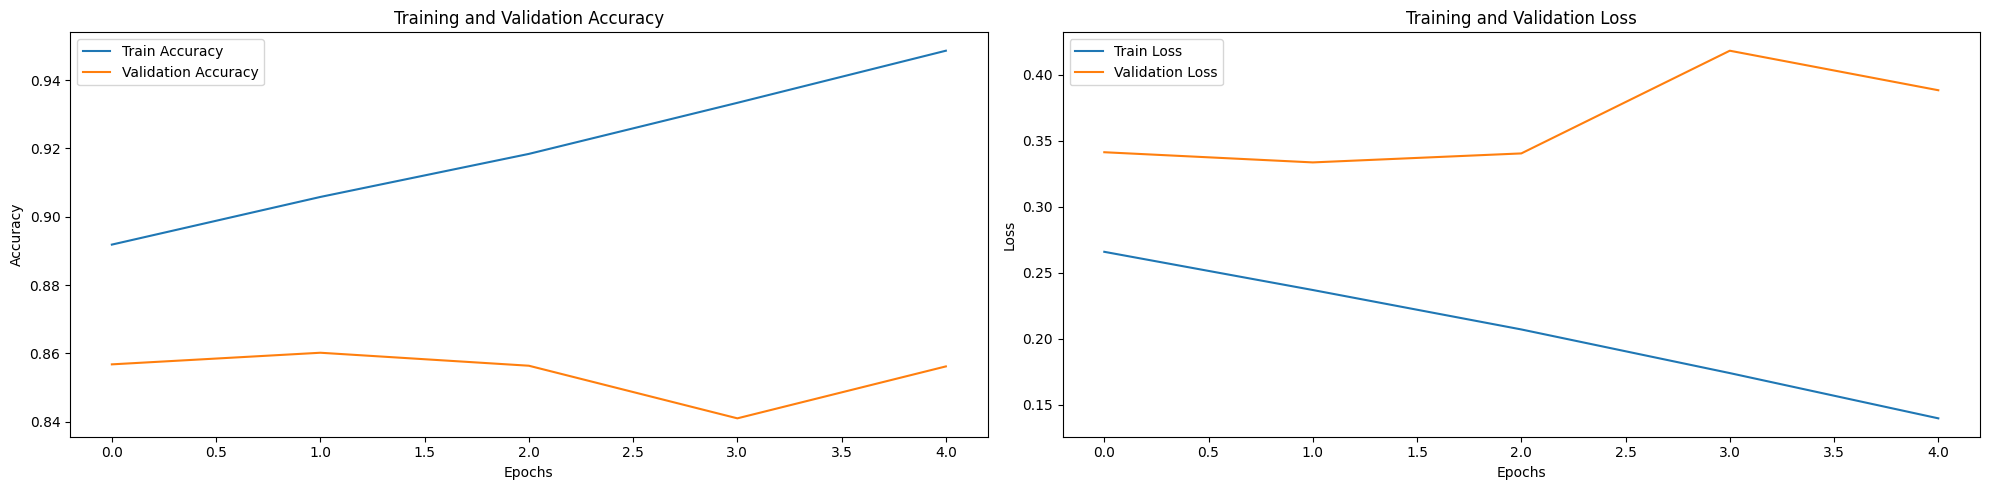

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 5)) # 1 row, 2 columns

# Plotting Accuracy
axes[0].plot(lstm_history.history['accuracy'])
axes[0].plot(lstm_history.history['val_accuracy'])
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend(['Train Accuracy', 'Validation Accuracy'])
axes[0].set_title('Training and Validation Accuracy')

# Plotting Loss
axes[1].plot(lstm_history.history['loss'])
axes[1].plot(lstm_history.history['val_loss'])
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend(['Train Loss', 'Validation Loss'])
axes[1].set_title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [ ]:
model.fit(X_train,y_train,
          epochs=10,
          initial_epoch=5,
          batch_size=32,
          validation_data=(X_test, y_test))

In [ ]:
model.fit(X_train,y_train,
          epochs=30,
          initial_epoch=10,
          batch_size=32,
          validation_data=(X_test, y_test))